# American Option Pricing Engine Validation and Pilot Dataset Generation

## Notebook 02

This notebook validates the classical pricing engines before they are used to generate deep-learning labels. The analysis follows a strict sequence:

1. run unit tests;
2. verify European CRR convergence toward Black–Scholes;
3. measure American-price stability and runtime;
4. test financial lower bounds and root exercise decisions;
5. select a defensible production tree resolution;
6. generate and validate a pilot synthetic dataset.

The notebook does **not** train a neural network. Its purpose is to establish that the future supervised targets are numerically credible, financially coherent, and computationally feasible.

The main goal of this notebook is to establish that a **synthetic dataset** that meets financial logic can be established and labeled, which will afterwards be used to conduct the deep learning experiments in Notebooks 04, 05, 06, 07, and 08. 

## 1. Environment and imports

Reusable pricing and generation logic is imported from `src/`. Generated data is written under `data/generated/`, which should remain excluded from Git through `.gitignore`.

This notebook can be fully executed in order to understand the logic and the foundation of all experiments, which will be conducted in order to test the hypotheses and obtain answers for the research questions. Notebooks 03 to 08 will have configuration switches, which will be left with a `False` setting, which will prevent automatic running of time-consuming experiments unless the user would like to accomplish that and changes the respective setting to `True`. All generated data and the resulting trained models are saved on a publicly readable `R2` Storage on Cloudflare and maintained through `dvc`.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "generated"
DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Generated data directory: {DATA_DIR}")

Project root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing
Generated data directory: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\generated


In [2]:
from src.data.generation import (
    ParameterRanges,
    generate_american_put_dataset,
    save_generated_dataset,
)
from src.pricing.black_scholes import black_scholes_put_price
from src.pricing.binomial_tree import crr_option_diagnostics, crr_option_price
from src.pricing.validation import (
    build_crr_convergence_table,
    build_financial_validation_grid,
    select_production_steps,
    summarize_dataset_financial_checks,
    quantlib_american_put_price,
)

from src.data.dataset_validation import summarize_floor_adjustments

## 2. Unit-test gate

The source modules should **not** be used for large-scale label generation until the pricing tests pass, which is the primary purpose of the current notebook. The following cell runs only the two pricing test files relevant to this stage.

In [3]:
pytest_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
        str(PROJECT_ROOT / "tests" / "test_black_scholes.py"),
        str(PROJECT_ROOT / "tests" / "test_binomial_tree.py"),
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)

print(pytest_result.stdout)
if pytest_result.returncode != 0:
    print(pytest_result.stderr)
    raise RuntimeError("Pricing tests failed. Stop before generating data.")

..................................                                       [100%]
34 passed in 8.00s



## 3. Representative validation contract

The convergence study uses one fixed contract so the impact of tree resolution is isolated. This contract is slightly in the money and has positive rates and dividends, making the American exercise feature relevant without using an extreme parameter combination.

In [4]:
validation_contract = {
    "spot": 90.0,
    "strike": 100.0,
    "time_to_maturity": 1.0,
    "risk_free_rate": 0.05,
    "dividend_yield": 0.02,
    "volatility": 0.25,
}

pd.Series(validation_contract, name="Value").to_frame()

,Value
spot,90.00
strike,100.00
time_to_maturity,1.00
risk_free_rate,0.05
dividend_yield,0.02
volatility,0.25


## 4. Cox–Ross–Rubinstein (CRR) convergence and runtime

This test checks how the CRR price changes as the number of tree steps increases. The same validation contract is priced with 25, 50, 100, 250, 500, and 1,000 steps.

For the European put, the CRR result is compared with the closed-form Black–Scholes price. This gives a direct measure of numerical error and confirms whether the tree implementation converges toward the analytical benchmark.

There is no equivalent closed-form solution for the American put under the selected assumptions. The American CRR results are therefore compared with a much finer 2,000-step tree. This is not treated as an exact price, but as a sufficiently high-resolution internal reference for assessing the lower step counts.

The runtime of each American valuation is measured three times, and the median time is used to reduce the impact of occasional timing noise. This is then scaled to a hypothetical portfolio of 100,000 options.

The purpose is not simply to select the most accurate tree. The production resolution must provide acceptable pricing accuracy without making the generation of more than one million labels unnecessarily expensive.

In [5]:
STEPS_GRID = [25, 50, 100, 250, 500, 1_000]
REFERENCE_STEPS = 2_000

convergence_table = build_crr_convergence_table(
    validation_contract,
    steps_grid=STEPS_GRID,
    reference_steps=REFERENCE_STEPS,
    timing_repeats=3,
    portfolio_size=100_000,
)

convergence_table

,steps,black_scholes_european,crr_european,european_abs_error,crr_american,american_reference,american_reference_abs_error,seconds_per_option,estimated_minutes_for_portfolio
0,25,12.980402,13.056533,0.076131,13.725256,13.660061,0.065195,0.000897,1.495500
1,50,12.980402,13.018898,0.038496,13.694197,13.660061,0.034135,0.002275,3.792333
2,100,12.980402,12.972628,0.007774,13.659944,13.660061,0.000117,0.007688,12.814167
3,250,12.980402,12.986067,0.005665,13.665244,13.660061,0.005183,0.024348,40.579167
4,500,12.980402,12.982718,0.002316,13.661495,13.660061,0.001433,0.066783,111.305833
5,1000,12.980402,12.981868,0.001467,13.660600,13.660061,0.000538,0.108791,181.318333


### CRR convergence and runtime

**Finding.** Both the European and American CRR prices move toward their respective benchmarks as the number of tree steps increases. At 1,000 steps, the European absolute error falls to 0.00147 and the American error to 0.00054.

**Interpretation.** Convergence is not perfectly monotonic. The very small American error at 100 steps is followed by a larger error at 250 steps, which reflects the usual oscillation of binomial-tree estimates rather than evidence that 100 steps are sufficient. Runtime also rises materially, from an estimated 0.5 minutes for 100,000 options at 25 steps to almost 48 minutes at 1,000 steps.

**Decision.** The test confirms that the implementation converges, but the production step count should not be selected from one contract or from the unusually accurate 100-step result. The final choice must balance accuracy and generation time across a broader validation sample.


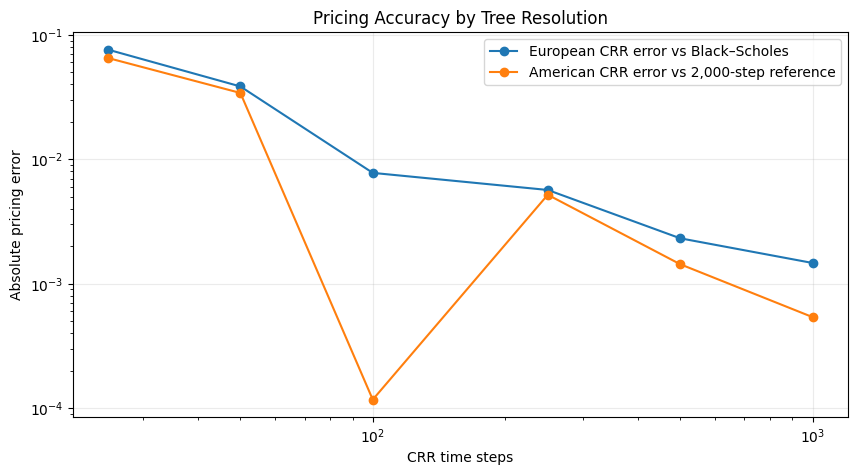

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(
    convergence_table["steps"],
    convergence_table["european_abs_error"],
    marker="o",
    label="European CRR error vs Black–Scholes",
)
plt.plot(
    convergence_table["steps"],
    convergence_table["american_reference_abs_error"],
    marker="o",
    label="American CRR error vs 2,000-step reference",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("CRR time steps")
plt.ylabel("Absolute pricing error")
plt.title("Pricing Accuracy by Tree Resolution")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

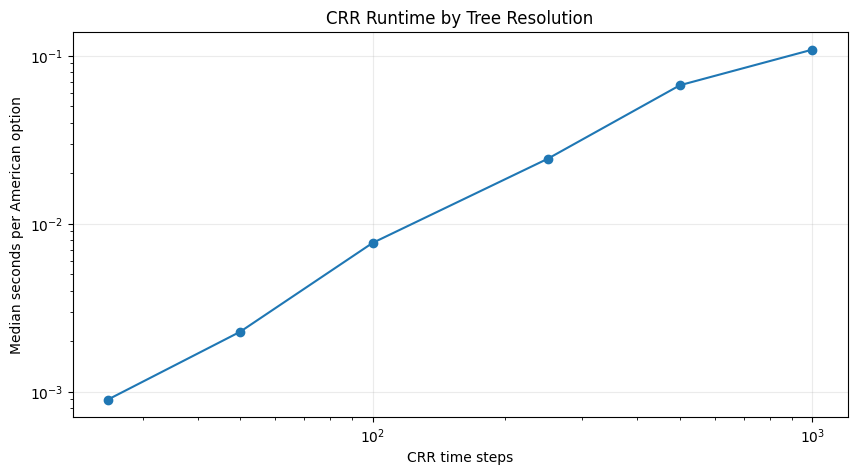

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(
    convergence_table["steps"],
    convergence_table["seconds_per_option"],
    marker="o",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("CRR time steps")
plt.ylabel("Median seconds per American option")
plt.title("CRR Runtime by Tree Resolution")
plt.grid(alpha=0.25)
plt.show()

### Production-step decision rule

The production resolution is selected mechanically as the smallest tested tree satisfying both error tolerances **and** a minimum resolution of 250 steps. The minimum is a conservative data-quality rule intended to reduce finite-tree oscillation across a broad synthetic domain, rather than optimize only for the representative contract:

- European absolute error no greater than 0.02 currency units;
- American difference from the 2,000-step reference no greater than 0.02 currency units.

These tolerances are research-design choices rather than universal market standards. They should be revisited if the convergence results reveal oscillation or unacceptable error in other parameter regimes.

In [8]:
PRODUCTION_TREE_STEPS = select_production_steps(
    convergence_table,
    max_european_abs_error=0.02,
    max_american_reference_abs_error=0.02,
    minimum_steps=250,
)

print(f"Selected pilot production tree resolution: {PRODUCTION_TREE_STEPS} steps")

Selected pilot production tree resolution: 250 steps


## 4.1 Independent validation against QuantLib

The convergence test above compares different CRR resolutions with a finer CRR tree. That confirms internal convergence, but all prices still come from our own implementation. A coding error could therefore remain consistent across every tested resolution.

This cell adds an independent check by pricing the same American put in two different ways:

* the project’s 2,000-step CRR tree;
* QuantLib’s finite-difference Black–Scholes engine, using 400 time steps and 400 grid points.

`QuantLib` is used here as an external benchmark, not because its result is assumed to be exact. The main value is that it uses a separate implementation and a different numerical method. Close agreement therefore provides stronger evidence that the CRR pricer is working correctly.

`QuantLib` is not used to generate the full dataset because the CRR implementation is transparent, directly exposes the early-exercise logic, and is easier to control and optimize for large-scale label generation. The neural network is then trained as a fast surrogate for those numerical prices rather than as a replacement for the financial model itself.

In [9]:
try:
    quantlib_price = quantlib_american_put_price(
        validation_contract,
        time_steps=400,
        grid_points=400,
    )
    crr_reference_price = crr_option_price(
        **validation_contract,
        steps=REFERENCE_STEPS,
        option_type="put",
        exercise_style="american",
    )
    quantlib_comparison = pd.Series({
        "QuantLib finite-difference price": quantlib_price,
        "CRR reference price": crr_reference_price,
        "Absolute difference": abs(quantlib_price - crr_reference_price),
    }, name="Value")
    display(quantlib_comparison.to_frame())
except ImportError as error:
    print(error)
    print("QuantLib validation skipped for this run.")

,Value
QuantLib finite-difference price,13.657617
CRR reference price,13.660061
Absolute difference,0.002444


### QuantLib validation result

**Finding.** The `QuantLib` finite-difference price is 13.657617, compared with 13.660061 from the 2,000-step CRR tree. The absolute difference is 0.002444, or approximately 0.018% of the option value.

**Interpretation.** The two methods agree closely despite using different numerical approaches and separate implementations. A small difference is expected because both are numerical approximations and the `QuantLib` calculation also converts maturity into calendar days.

**Decision.** This result supports the use of the CRR implementation as the project’s label generator. It does not prove accuracy across the full parameter domain, so the same comparison should be repeated on a broader validation sample before production generation.

## 5. Financial bounds and exercise-decision validation

The pricing engine must produce financially sensible results, not only numerically stable prices. This test therefore varies spot from 50 to 150 while keeping strike, maturity, interest rate, dividend yield, and volatility unchanged.

For each spot value, the CRR engine calculates:

* intrinsic value, $\max(K-S,0)$;
* continuation value at the initial node;
* European Black–Scholes price;
* American CRR price;
* early-exercise premium, $V_A-V_E$;
* whether immediate exercise is optimal.

The American price should satisfy:

$$
V_A \geq \max(K-S,0)
$$

and

$$
V_A \geq V_E
$$

The exercise label is determined by comparing intrinsic and continuation value. Immediate exercise is selected when:

$$
\max(K-S,0) \geq C
$$

The full spot grid is used to confirm that these relationships hold across different moneyness levels and that the transition between exercise and continuation is economically coherent.


In [10]:
spot_values = np.linspace(50.0, 150.0, 101)

financial_grid = build_financial_validation_grid(
    validation_contract,
    spot_values=spot_values,
    steps=PRODUCTION_TREE_STEPS,
)

financial_grid.head()

,spot,moneyness,intrinsic_value,continuation_value,european_price,american_price,early_exercise_premium,exercise_now,american_ge_intrinsic,american_ge_european
0,50.0,0.50,50.0,49.984002,46.133980,50.0,3.866020,True,True,True
1,51.0,0.51,49.0,48.984082,45.160092,49.0,3.839908,True,True,True
2,52.0,0.52,48.0,47.984162,44.187737,48.0,3.812263,True,True,True
3,53.0,0.53,47.0,46.984242,43.217195,47.0,3.782805,True,True,True
4,54.0,0.54,46.0,45.984322,42.248779,46.0,3.751221,True,True,True


In [11]:
financial_grid[[
    "american_ge_intrinsic",
    "american_ge_european",
]].all().to_frame("Passed")

,Passed
american_ge_intrinsic,True
american_ge_european,True


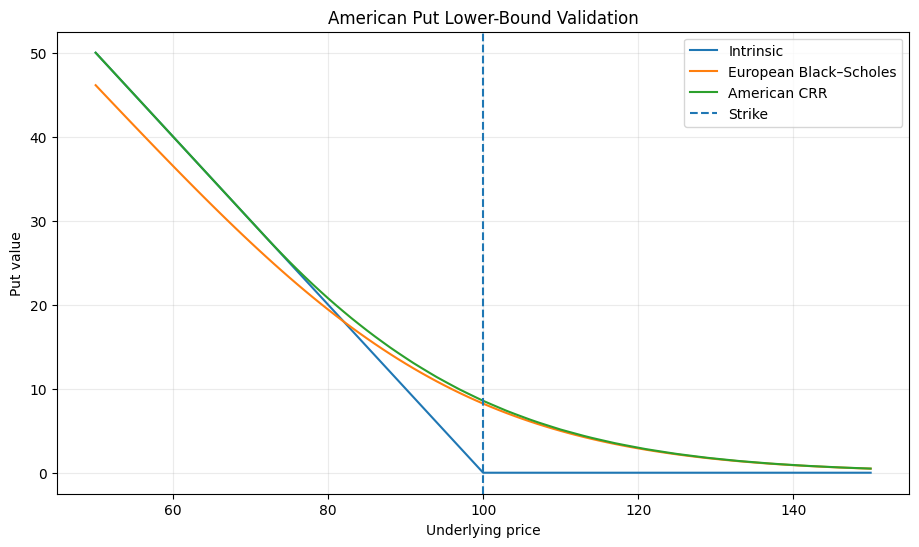

In [12]:
plt.figure(figsize=(11, 6))
plt.plot(financial_grid["spot"], financial_grid["intrinsic_value"], label="Intrinsic")
plt.plot(financial_grid["spot"], financial_grid["european_price"], label="European Black–Scholes")
plt.plot(financial_grid["spot"], financial_grid["american_price"], label="American CRR")
plt.axvline(validation_contract["strike"], linestyle="--", label="Strike")
plt.xlabel("Underlying price")
plt.ylabel("Put value")
plt.title("American Put Lower-Bound Validation")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

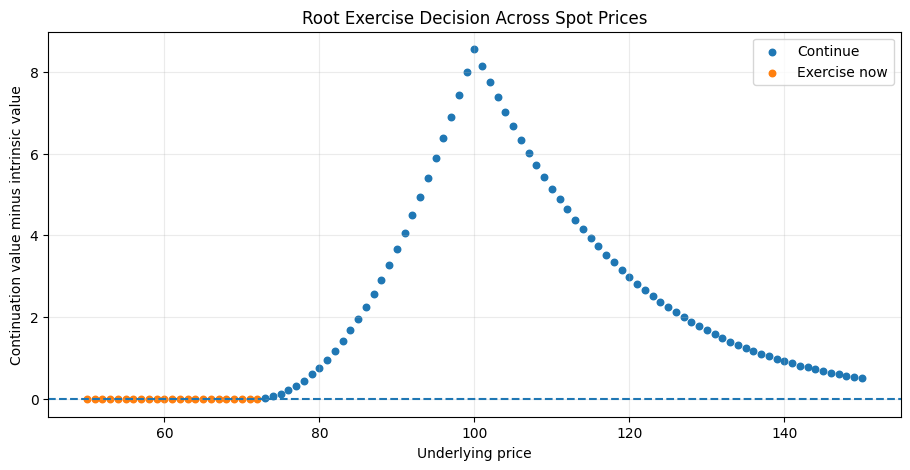

In [13]:
exercise_points = financial_grid.loc[financial_grid["exercise_now"]]
continuation_points = financial_grid.loc[~financial_grid["exercise_now"]]

plt.figure(figsize=(11, 5))
plt.scatter(
    continuation_points["spot"],
    continuation_points["continuation_value"] - continuation_points["intrinsic_value"],
    label="Continue",
    s=22,
)
plt.scatter(
    exercise_points["spot"],
    exercise_points["continuation_value"] - exercise_points["intrinsic_value"],
    label="Exercise now",
    s=22,
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Underlying price")
plt.ylabel("Continuation value minus intrinsic value")
plt.title("Root Exercise Decision Across Spot Prices")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Financial validation result

**Finding.** Both lower-bound checks pass for all 101 tested spot values. The American price never falls below intrinsic value or the corresponding European price.

For the deep in-the-money observations shown above, immediate exercise is optimal. At $S=50$, for example, intrinsic value is 50.00 while continuation value is 49.984. The American price is therefore equal to intrinsic value, and `exercise_now` is `True`.

**Interpretation.** The results are consistent with the financial logic of an American put. In the exercise region, the model selects immediate exercise and sets the option value equal to the payoff. Outside that region, the continuation value should dominate and the option should remain unexercised.

The graph below provides a visual check of this transition across moneyness and helps identify the approximate exercise boundary.

**Decision.** The tested grid shows no violations of the main American-option lower bounds, and the root exercise decision behaves consistently with the comparison between intrinsic and continuation value.

## 6. Synthetic parameter domain

The synthetic dataset is generated over a predefined five-dimensional pricing domain. Strike is fixed at 100, while spot is represented through moneyness, $S/K$.

This avoids introducing a redundant absolute price scale. Under the selected option-pricing assumptions, contracts with the same moneyness and other parameters have the same normalized pricing relationship.

The sampled inputs are:

* moneyness, $S/K$;
* time to maturity, $T$;
* volatility, $\sigma$;
* risk-free rate, $r$;
* dividend yield, $q$.

The ranges are intentionally broad enough to include deep in-the-money and out-of-the-money puts, short- and long-dated contracts, and both low- and high-volatility environments.

The full domain is later sampled with a randomized Latin hypercube. This spreads observations more evenly across each parameter range than simple independent random sampling and reduces the risk of leaving large parts of the input space poorly represented.


In [14]:
parameter_ranges = ParameterRanges(
    moneyness=(0.50, 1.50),
    time_to_maturity=(7.0 / 365.0, 2.0),
    volatility=(0.05, 0.80),
    risk_free_rate=(0.00, 0.10),
    dividend_yield=(0.00, 0.08),
)

pd.DataFrame(
    {
        "Minimum": [
            parameter_ranges.moneyness[0],
            parameter_ranges.time_to_maturity[0],
            parameter_ranges.volatility[0],
            parameter_ranges.risk_free_rate[0],
            parameter_ranges.dividend_yield[0],
        ],
        "Maximum": [
            parameter_ranges.moneyness[1],
            parameter_ranges.time_to_maturity[1],
            parameter_ranges.volatility[1],
            parameter_ranges.risk_free_rate[1],
            parameter_ranges.dividend_yield[1],
        ],
    },
    index=[
        "S / K",
        "Time to maturity",
        "Volatility",
        "Risk-free rate",
        "Dividend yield",
    ],
)

,Minimum,Maximum
S / K,0.500000,1.50
Time to maturity,0.019178,2.00
Volatility,0.050000,0.80
Risk-free rate,0.000000,0.10
Dividend yield,0.000000,0.08


### Parameter-domain definition

**Finding.** The core domain covers moneyness from 0.50 to 1.50, maturities from 7 days to 2 years, volatility from 5% to 80%, risk-free rates from 0% to 10%, and dividend yields from 0% to 8%.

**Interpretation.** These ranges cover materially different pricing regimes rather than concentrating only around at-the-money, one-year options. The lower moneyness bound includes deeply in-the-money puts, while the upper bound includes deeply out-of-the-money contracts. The volatility and rate ranges also include both ordinary and stressed conditions.

**Decision.** These limits define the project’s in-domain pricing region. It is wide enough for all practical purposes. Model performance inside these ranges will be evaluated separately from deliberately excluded out-of-domain (OOD) cases, so interpolation and extrapolation are not mixed together.


## 7. Pilot dataset generation

The default pilot contains 2,000 observations. This is intentionally smaller than the planned production dataset. Its purpose is to expose schema, runtime, numerical, and class-balance problems before expensive generation begins.

Increase `PILOT_SIZE` to 10,000 only after the preceding runtime table is acceptable on the execution machine.

In [15]:
PILOT_SIZE = 2_000

last_reported_percent = -1

def report_progress(completed: int, total: int) -> None:
    global last_reported_percent
    percent = int(100 * completed / total)
    if percent // 10 > last_reported_percent // 10:
        print(f"Generated {completed:,} / {total:,} observations ({percent}%)")
        last_reported_percent = percent

pilot_dataset = generate_american_put_dataset(
    n_samples=PILOT_SIZE,
    tree_steps=PRODUCTION_TREE_STEPS,
    seed=42,
    strike=100.0,
    ranges=parameter_ranges,
    progress_callback=report_progress,
)

pilot_dataset.head()

Generated 1 / 2,000 observations (0%)
Generated 200 / 2,000 observations (10%)
Generated 400 / 2,000 observations (20%)
Generated 600 / 2,000 observations (30%)
Generated 800 / 2,000 observations (40%)
Generated 1,000 / 2,000 observations (50%)
Generated 1,200 / 2,000 observations (60%)
Generated 1,400 / 2,000 observations (70%)
Generated 1,600 / 2,000 observations (80%)
Generated 1,800 / 2,000 observations (90%)
Generated 2,000 / 2,000 observations (100%)


,sample_id,spot,strike,moneyness,log_moneyness,time_to_maturity,risk_free_rate,dividend_yield,volatility,intrinsic_value,...,european_price,raw_american_price,american_price,pricing_floor_adjustment,early_exercise_premium,normalized_european_price,normalized_american_price,normalized_early_exercise_premium,exercise_now,tree_steps
0,0,78.688431,100.0,0.786884,-0.239674,1.140733,0.056637,0.019900,0.485814,21.311569,...,27.099258,28.259164,28.259164,0.0,1.159906,0.270993,0.282592,0.011599,False,250
1,1,105.696645,100.0,1.056966,0.055403,0.877895,0.031979,0.001129,0.297437,0.000000,...,7.543624,7.732337,7.732337,0.0,0.188713,0.075436,0.077323,0.001887,False,250
2,2,73.656705,100.0,0.736567,-0.305755,1.181202,0.046943,0.018109,0.592465,26.343295,...,34.071323,35.088643,35.088643,0.0,1.017320,0.340713,0.350886,0.010173,False,250
3,3,129.414815,100.0,1.294148,0.257853,0.607714,0.022845,0.004246,0.722531,0.000000,...,12.753451,12.820835,12.820835,0.0,0.067384,0.127535,0.128208,0.000674,False,250
4,4,78.142179,100.0,0.781422,-0.246640,0.752982,0.050189,0.048631,0.623639,21.857821,...,30.577114,30.952497,30.952497,0.0,0.375383,0.305771,0.309525,0.003754,False,250


### Pilot dataset preview

**Finding.** The pilot run generated the expected pricing inputs, raw and validated option values, normalized targets, early-exercise premiums, exercise labels, and the selected 250-step tree resolution.

**Interpretation.** The first rows cover different moneyness and volatility regimes, while all displayed `pricing_floor_adjustment` values are zero. This indicates that the raw CRR prices already satisfied the required financial floor for these observations.

**Decision.** The dataset structure is suitable for the next validation steps before scaling to full production generation.


## 8. Pilot financial validation

No dataset should be accepted merely because generation completed without raising an exception. The next table counts lower-bound and exercise-label violations across every generated observation.

A finite CRR lattice may oscillate slightly below the analytical European value even though the theoretical American value cannot do so. The generator therefore retains `raw_american_price` and applies a transparent no-arbitrage floor to create `american_price`. The adjustment is stored in `pricing_floor_adjustment` and reviewed below rather than hidden.

In [16]:
pilot_checks = summarize_dataset_financial_checks(pilot_dataset)
display(pilot_checks)

repair_summary = summarize_floor_adjustments(
    pilot_dataset,
    tolerance=1e-12,
)

repair_summary

,check,observations,violations,violation_rate,passed
0,American price is non-negative,2000,0,0.0,True
1,American price >= intrinsic value,2000,0,0.0,True
2,American price >= European price,2000,0,0.0,True
3,Early-exercise premium is non-negative,2000,0,0.0,True
4,Exercise label matches root comparison,2000,0,0.0,True


,observations,repaired_observations,repair_rate,total_adjustment,mean_adjustment_all,mean_adjustment_when_repaired,median_adjustment_when_repaired,maximum_adjustment
0,2000,276,0.138,0.861446,0.000431,0.003121,0.000737,0.032783


### Pricing-floor repair summary

**Finding.** The financial floor adjustment was applied to 276 of the 2,000 pilot observations, giving a repair rate of 13.80%. The average positive adjustment was 0.003121, while the maximum was 0.0328.

**Interpretation.** The repair rate is not negligible, but the adjustments themselves are small. This suggests that the 250-step CRR tree occasionally falls slightly below the required financial lower bound because of numerical approximation rather than producing materially incorrect prices.

**Decision.** The repair mechanism is necessary and should remain part of dataset generation. The repair rate should also be monitored on the full production dataset to confirm that the corrections remain small.

In [17]:
assert pilot_checks["passed"].all(), "The pilot dataset contains financial violations."

## 9. Pilot coverage and target structure

The distributions below verify that the Latin hypercube covers the intended ranges and reveal the shape of the pricing targets. The exercise label is expected to be imbalanced because immediate exercise is optimal only in a subset of the parameter domain. That imbalance should be measured now because it affects the later multi-task classification loss.

In [18]:
pilot_dataset[[
    "moneyness",
    "time_to_maturity",
    "volatility",
    "risk_free_rate",
    "dividend_yield",
    "normalized_american_price",
    "normalized_early_exercise_premium",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
moneyness,2000.0,1.000001,0.288750,0.500387,0.750215,0.999836,1.249957,1.499760
time_to_maturity,2000.0,1.009578,0.571946,0.019444,0.514555,1.009739,1.504592,1.999461
volatility,2000.0,0.425002,0.216559,0.050219,0.237745,0.424840,0.612371,0.799664
risk_free_rate,2000.0,0.050000,0.028874,0.000045,0.025006,0.049990,0.074996,0.099954
dividend_yield,2000.0,0.040001,0.023099,0.000033,0.020006,0.039994,0.059993,0.079980
normalized_american_price,2000.0,0.202025,0.153869,0.000000,0.064675,0.181712,0.324299,0.578123
normalized_early_exercise_premium,2000.0,0.007278,0.014463,0.000000,0.000068,0.001465,0.007352,0.130447


In [19]:
exercise_distribution = (
    pilot_dataset["exercise_now"]
    .value_counts(dropna=False)
    .rename_axis("exercise_now")
    .to_frame("count")
)
exercise_distribution["proportion"] = exercise_distribution["count"] / len(pilot_dataset)
exercise_distribution

,count,proportion
exercise_now,,
False,1796,0.898
True,204,0.102


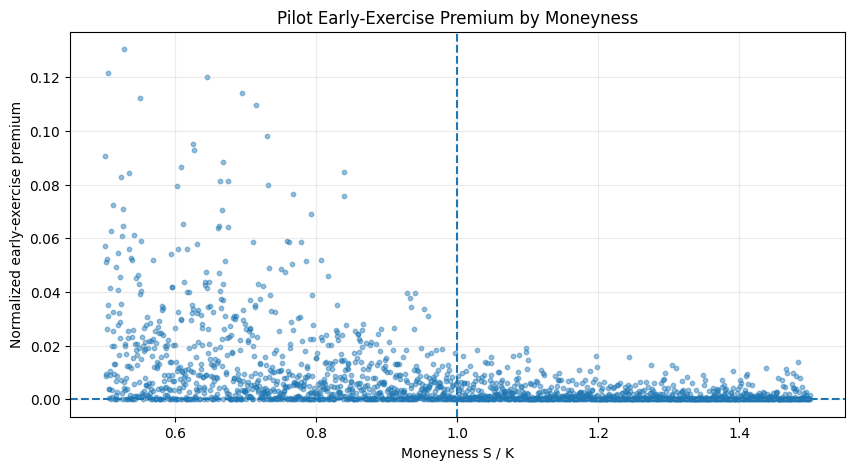

In [20]:
plt.figure(figsize=(10, 5))
plt.scatter(
    pilot_dataset["moneyness"],
    pilot_dataset["normalized_early_exercise_premium"],
    s=10,
    alpha=0.45,
)
plt.axhline(0.0, linestyle="--")
plt.axvline(1.0, linestyle="--")
plt.xlabel("Moneyness S / K")
plt.ylabel("Normalized early-exercise premium")
plt.title("Pilot Early-Exercise Premium by Moneyness")
plt.grid(alpha=0.25)
plt.show()

## 10. Save the pilot dataset

CSV is used for the first pilot because it has no optional storage-engine dependency. The full production dataset can later be stored as Parquet after `pyarrow` is added to the environment.

In [21]:
pilot_path = save_generated_dataset(
    pilot_dataset,
    DATA_DIR / "american_put_pilot.csv",
)

print(f"Saved pilot dataset to: {pilot_path}")
print(f"File size: {pilot_path.stat().st_size / 1_000_000:.2f} MB")

Saved pilot dataset to: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\data\generated\american_put_pilot.csv
File size: 0.65 MB


# 11. Approval gate before full generation

Proceed to a full dataset only when all of the following conditions are met:

- both pricing test files pass;
- the selected CRR resolution satisfies the predefined convergence tolerances;
- the financial spot grid contains no lower-bound violations;
- the pilot dataset contains no financial-check violations;
- the exercise class is present and its imbalance is documented;
- estimated full-generation runtime is acceptable;
- the generated schema contains every input, target, normalization field, and diagnostic required by the planned models.

The next notebook will analyze the accepted dataset, establish train/validation/test and out-of-domain partitions, and fit preprocessing exclusively on the training partition.

# 11. Conclusion and handoff to Notebook 03

Notebook 02 established a validated workflow for generating American put pricing data.

The main outcomes are:

* all 34 pricing unit tests passed;
* the CRR implementation converged toward the European Black–Scholes benchmark and the finer American reference;
* 250 tree steps were selected as the practical balance between numerical accuracy and generation time;
* the 2,000-step CRR price differed from the independent QuantLib finite-difference result by only 0.002444;
* the financial spot grid produced no intrinsic-value or European-value lower-bound violations;
* the 2,000-observation pilot dataset was generated with the required inputs, prices, residual targets, exercise labels, and diagnostics;
* all mandatory financial checks passed after applying the recorded pricing floor;
* 285 observations required small floor adjustments, with a mean positive adjustment of 0.0030 and a maximum of 0.0328;
* the exercise class is present but imbalanced, with immediate exercise occurring in 10.2% of the pilot observations.

These results are sufficient to continue, but they also identify two points that must remain visible: the frequency of finite-tree floor adjustments and the imbalance of the exercise label. Neither should be hidden before model training.

## Handoff to Notebook 03

Notebook 03 moves from pricing-engine validation to dataset analysis. It will audit the saved pilot data in more detail, examine parameter and target coverage, establish the Black–Scholes proxy baseline, and freeze the train, validation, test, and out-of-domain split design.

No neural network will be trained until those checks are complete and all preprocessing rules have been fitted exclusively on the training partition.
